Ce notebook est constitué de 2 parties :
- la partie 1 le principe explique la théorie derrière l'algorithme, il n'y a quasiment pas de code (mis à part pour montrer quelques résultats visuels)
- la partie 2 le code implémente ce qui a été vu dans la partie 1

### - **Le principe**

Le but du projet est d'implémenter l'algorithme LSD pour détecter des segments de ligne dans des images numériques.
L'algorithme LSD est conçu pour détecter des contours localement droits dans les images, appelés segments de ligne, sans nécessiter de réglage de paramètres. Il fonctionne en temps linéaire et donne des résultats précis au sous-pixel.

### 1 - Mise à l'échelle de l'image
 
L'objectif de la première étape est la mise à l'échelle de l'image d'entrée. Ce procédé permet de réduire les artefacts d'aliasing et de quantification qui peuvent affecter la précision de la détection des segments de ligne. Ces artefacts sont particulièrement problématiques dans les images numériques où les transitions entre les niveaux de gris peuvent créer des effets de "staircase" (effet d'escalier) et d'autres anomalies visuelles.

 **L'intérêt pour l'algorithme LSD** : 

![Exemple : Représentation de contours discrets sous deux angles et détections sans mise à l'échelle.](figures6.png)

**Figure A : Représentation de contours discrets sous deux angles et détections sans mise à l'échelle.**


Cette première figure montre deux contours discrets à différents angles, tous deux présentant l'effet d'escalier. 
À côté de chaque image se trouve le résultat du LSD sans utiliser le redimensionnement initial. Dans le premier cas, le contour est détecté comme quatre segments de ligne horizontaux au lieu d'un seul ; dans le deuxième cas, aucun segment de ligne n'est détecté.
Dans les deux cas de la figure A, le résultat est raisonnable, mais il ne correspond pas aux attentes.

![Exemple : Détections pour les images de la figure A, mais en utilisant le redimensionnement.](figure7.png)

**Figure B : Détections pour les images de la figure A, mais en utilisant le redimensionnement.**

La figure B montre le résultat du LSD, en utilisant le redimensionnement à 80%. Les deux contours sont maintenant détectés et avec la bonne orientation (même si le premier est encore fragmenté).

Le facteur d'échelle de 80 % (S=0.8) représente le plus petit facteur de réduction d'image qui résout raisonnablement le problème d'escalier tout en produisant presque les mêmes résultats qu'une analyse à pleine échelle sur des images sans artefacts. (Une mise à l'échelle de 80 % signifie ici que les axes x et y sont chacun réduits à 80 %, ce qui réduit le nombre de pixels à 64 %.)

La mise à l'échelle est réalisée par un sous-échantillonnage gaussien : l'image est filtrée avec un noyau gaussien pour éviter l'aliasing, puis sous-échantillonnée. L'écart-type du noyau gaussien est déterminé par $\sigma = \Sigma / S$, où S est le facteur d'échelle. La valeur de $\Sigma$ est fixée à 0,6, ce qui offre un bon compromis entre la prévention de l'aliasing et la réduction du flou de l'image.


***Implémentons l'algorithme de redimmensionnement sur un exemple*** :






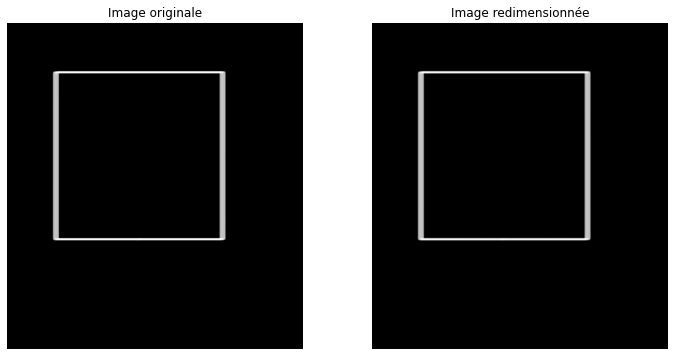

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def scale_image(input_image, scale=0.8, sigma=0.75):
    # Appliquer le filtre gaussien pour éviter l'aliasing
    blurred_image = cv2.GaussianBlur(input_image, (0, 0), sigma)
    
    # Redimensionner l'image
    height, width = blurred_image.shape
    new_width = int(width * scale)
    new_height = int(height * scale)
    output_image = cv2.resize(blurred_image, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
    
    return output_image

# Charger l'image téléchargée
input_image = cv2.imread('carre.jpg', cv2.IMREAD_GRAYSCALE)


# Redimensionner l'image
scaled_image = scale_image(input_image)

# Affichage des images originale et redimensionnée côte à côte
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(scaled_image, cmap='gray')
plt.title('Image redimensionnée')
plt.axis('off')

plt.show()




L'affichage des images montre que l'algorithme fonctionne comme prévu. L'application d'un flou gaussien avant le redimensionnement permet de réduire les aliasings, bien que cela entraîne une légère perte de netteté. Cette méthode est utile pour éviter les artefacts visuels lors du redimensionnement d'images.

## 2 - Calcul du Gradient

L'objectif de cette étape est de calculer le gradient de l'image à chaque pixel. Le gradient indique la direction et l'intensité du changement de niveau de gris, ce qui permet de détecter les contours dans l'image. Les contours sont des zones où le niveau de gris change rapidement, et ces zones sont les candidats potentiels pour les segments de ligne. 

### - Processus

1. **Calcul du Gradient** : Le gradient de l'image est calculé à chaque pixel en utilisant un masque $2 \times 2$. 

![](gradientmask.png)

Ce masque est choisi car il permet de minimiser la dépendance entre les valeurs de gradient calculées. L'utilisation d'un masque 2×2 permet de réduire la dépendance entre les valeurs de gradient calculées, ce qui est important pour l'approche a contrario. Cela permet également de minimiser les erreurs dues à la quantification des niveaux de gris.

2. **Formules** :



   - Soit $i(x, y)$ la valeur du niveau de gris de l'image au pixel $(x, y)$.
   - Le gradient en $x$ ($g_x$) et en $y$ ($g_y$) est calculé comme suit :

     $$
     g_x(x, y) = \frac{i(x + 1, y) + i(x + 1, y + 1) - i(x, y) - i(x, y + 1)}{2}
     $$

     $$
     g_y(x, y) = \frac{i(x, y + 1) + i(x + 1, y + 1) - i(x, y) - i(x + 1, y)}{2}
     $$

3. **L'orientation du gradient** :
   - L'orientation du gradient ou l'angle de la ligne de niveau ($\theta$) est calculé à partir des composantes $g_x(x,y)$ et $g_y(x,y)$ du gradient :

     $$
     \theta(x, y) = \arctan\left(\frac{g_x(x, y)}{-g_y(x, y)}\right)
     $$

4. **Module du gradient** :
   - Le module du gradient ($G$) est calculé comme suit :

     $$
     G(x, y) = \sqrt{g_x^2(x, y) + g_y^2(x, y)}
     $$



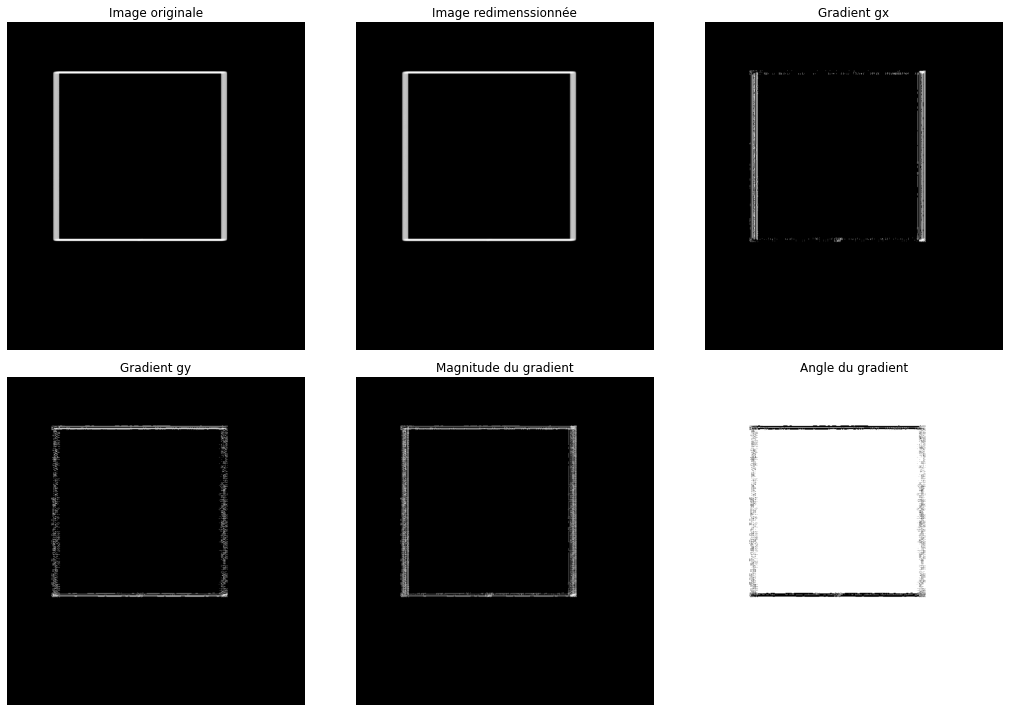

In [11]:
def scale_image(input_image, scale=0.8, sigma=0.75):
    # Appliquer le filtre gaussien pour éviter l'aliasing
    blurred_image = cv2.GaussianBlur(input_image, (0, 0), sigma)
    
    # Redimensionner l'image
    height, width = blurred_image.shape
    new_width = int(width * scale)
    new_height = int(height * scale)
    output_image = cv2.resize(blurred_image, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
    
    return output_image

def compute_gradient(image):
    gx = (image[1:, 1:] + image[:-1, 1:] - image[1:, :-1] - image[:-1, :-1]) / 2.0
    gy = (image[1:, 1:] + image[1:, :-1] - image[:-1, 1:] - image[:-1, :-1]) / 2.0
    gradient_magnitude = np.sqrt(gx**2 + gy**2)
    gradient_angle = np.arctan2(gy, -gx)
    return gx, gy, gradient_magnitude, gradient_angle

input_image = cv2.imread('carre.jpg', cv2.IMREAD_GRAYSCALE)


gx, gy, gradient_magnitude, gradient_angle = compute_gradient(input_image)

scaled_image = scale_image(input_image)


plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(scaled_image, cmap='gray')
plt.title('Image redimenssionnée')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gx, cmap='gray')
plt.title('Gradient gx')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(gy, cmap='gray')
plt.title('Gradient gy')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Magnitude du gradient')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(gradient_angle, cmap='gray')
plt.title('Angle du gradient')
plt.axis('off')

plt.tight_layout()
plt.show()




## Observations

1. **Gradient gx** :
   - Les gradients gx semblent montrer des lignes verticales claires et nettes, ce qui indique des changements importants dans l'intensité des pixels dans la direction x (horizontale).
   - Il y a beaucoup de bruit et des artefacts visibles, ce qui peut indiquer des bordures ou des erreurs de quantification.

2. **Gradient gy** :
   - Les gradients gy montrent des lignes horizontales claires et nettes, indiquant des changements importants dans l'intensité des pixels dans la direction y (verticale).
   - Comme pour gx, il y a beaucoup de bruit et des artefacts visibles.

3. **Magnitude du gradient** :
   - La magnitude du gradient combine les informations de gx et gy, mettant en évidence les changements d'intensité indépendamment de la direction.
   - Les bordures des carrés sont clairement visibles, ce qui est attendu, mais la présence de motifs répétitifs et de bruit indique des gradients très sensibles aux petites variations.

4. **Angle du gradient** :
   - L'angle du gradient montre les orientations des changements d'intensité. Les lignes diagonales et les motifs répétitifs peuvent être observés.
   - Il y a également beaucoup de bruit et d'artefacts, rendant l'interprétation de l'angle du gradient plus difficile.


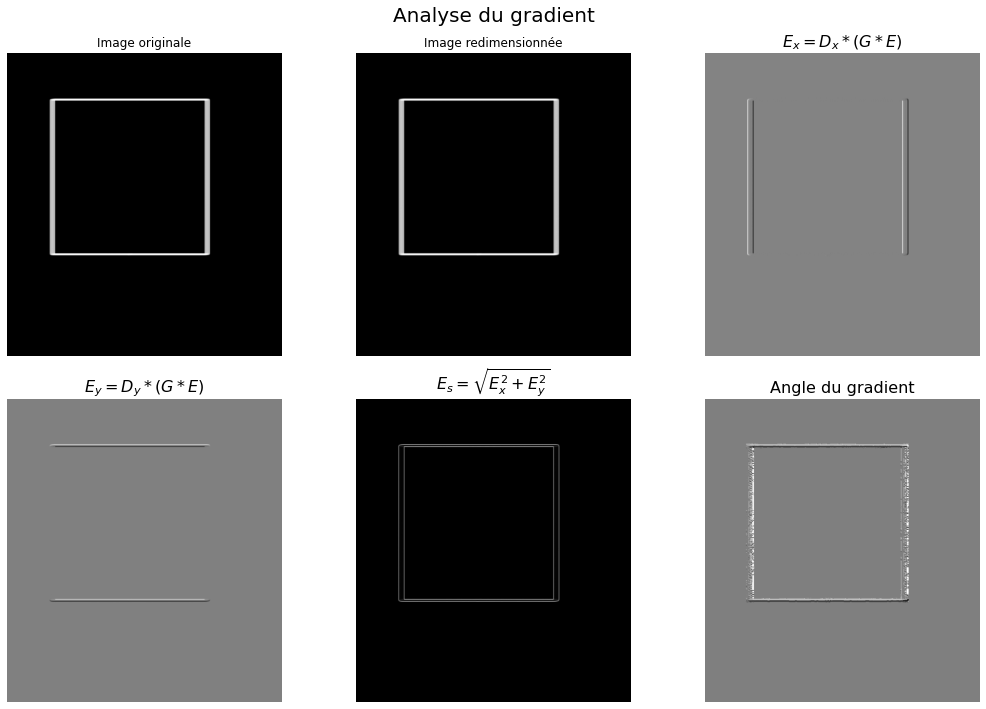

In [3]:

def compute_gradient(image):
    # Utiliser les filtres Sobel pour calculer les gradients
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(gx**2 + gy**2)
    gradient_angle = np.arctan2(gy, gx)
    return gx, gy, gradient_magnitude, gradient_angle

# Charger l'image téléchargée
input_image = cv2.imread('carre.jpg', cv2.IMREAD_GRAYSCALE)


# Appliquer la fonction compute_gradient
gx, gy, gradient_magnitude, gradient_angle = compute_gradient(input_image)

# Redimensionner l'image
scaled_image = scale_image(input_image)

# Affichage des résultats
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(scaled_image, cmap='gray')
plt.title('Image redimensionnée')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gx, cmap='gray')
plt.title(r"$E_x = D_x * (G * E)$", fontsize=16)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(gy, cmap='gray')
plt.title(r"$E_y = D_y * (G * E)$", fontsize=16)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title(r"$E_s = \sqrt{E_x^2 + E_y^2}$", fontsize=16)
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(gradient_angle, cmap='gray')
plt.title('Angle du gradient', fontsize=16)
plt.axis('off')

plt.suptitle("Analyse du gradient", fontsize=20)
plt.tight_layout()
plt.show()


## 3 - Pseudo-ordonnancement du gradient

L'objectif de cette étape est de trier les pixels de l'image en fonction du magnitude de leur gradient. Les pixels avec une magnitude élevée correspondent aux bords les plus contrastés de l'image et permet de traiter les pixels les plus significatifs en premier, optimisant ainsi l'efficacité et la précision de la détection des segments de ligne.

LSD est un algorithme glouton et l'ordre dans lequel les pixels sont traités impacte le résultat. Les pixels avec une magnitude de gradient élevée correspondent aux contours les plus contrastés. Dans un contour, les pixels centraux ont généralement la magnitude de gradient la plus élevée. Il est donc logique de commencer par chercher des segments de ligne aux pixels avec la plus grande magnitude de gradient.

Les algorithmes de tri nécessitent généralement des opérations de l'ordre de \(O(n \log n)\) pour trier \(n\) valeurs. Cependant, un pseudo-ordonnancement simple des pixels est possible en temps linéaire. À cet effet, 1024 bins sont créés correspondant à des intervalles égaux de magnitude de gradient entre zéro et la plus grande valeur observée sur l'image. Les pixels sont classés dans les bins selon leur magnitude de gradient. LSD utilise d'abord des pixels de départ du bin avec les plus grandes magnitudes de gradient ; puis il prend des pixels de départ du deuxième bin, et ainsi de suite jusqu'à l'épuisement de tous les bins. 1024 bins suffisent pour trier presque strictement les valeurs de gradient lorsque les niveaux de gris sont quantifiés dans la plage entière [0, 255].




In [1]:

def sort_pixels_by_gradient(gradient_magnitude):
    indices = np.argsort(-gradient_magnitude.flatten())  # Sort in descending order
    return indices




## 4 - Seuil de gradient

Cette étape est essentielle pour éliminer les pixels qui ne sont pas significatifs pour la détection des segments de ligne, en raison de leur faible module de gradient. Ces pixels correspondent généralement à des zones plates ou à des gradients lents dans l'image, où les changements de niveau de gris sont minimes. En éliminant ces pixels, l'algorithme se concentre sur les zones de l'image où les changements de niveau de gris sont suffisamment importants pour indiquer la présence de segments de ligne. 
De plus, ils présentent naturellement une erreur plus élevée dans le calcul du gradient en raison de la quantification de leurs valeurs. Dans l'algorithme, les pixels avec un module de gradient inférieure à $\rho$ sont donc éliminés et non utilisés dans la construction des régions de support de ligne ou des rectangles.

# Processus

1. **Calcul du seuil** : 

Le seuil de gradient, noté 𝜌, est calculé en fonction de la tolérance angulaire 𝜏 utilisée dans l'algorithme de croissance de région. Le seuil est déterminé de manière à ce que l'erreur angulaire due à la quantification soit inférieure à la tolérance 𝜏.

Supposons un bruit de quantification $n$ et une image propice $i$, nous observons :
$$
\tilde{i} = i + n \quad \nabla \tilde{i} = \nabla i + \nabla n.
$$

L'erreur angulaire est donnée par :

$$
|\text{erreur angulaire}| \leq \arcsin \left( \frac{q}{|\nabla i|} \right),
$$

où $q$ est une borne sur $|\nabla n|$. Le critère utilisé est de rejeter les pixels où l'erreur angulaire est supérieure à la tolérance angulaire $\tau$ utilisée dans l'algorithme de croissance de région. C'est-à-dire qu'on impose $|\text{erreur angulaire}| \leq \tau$ et nous obtenons

$$
\rho = \frac{q}{\sin \tau}.
$$

Le seuil $\rho$ est défini en utilisant la dernière expression où $q$ est une borne sur l'erreur possible dans la valeur du gradient due aux effets de quantification, et $\tau$ est la tolérance angulaire à utiliser dans l'algorithme de croissance régionale.

2. **Rejet des pixels**: Les pixels dont le module de gradient est inférieur à 𝜌 sont rejetés et ne sont pas utilisés dans la construction des régions de support de ligne ou des rectangles.






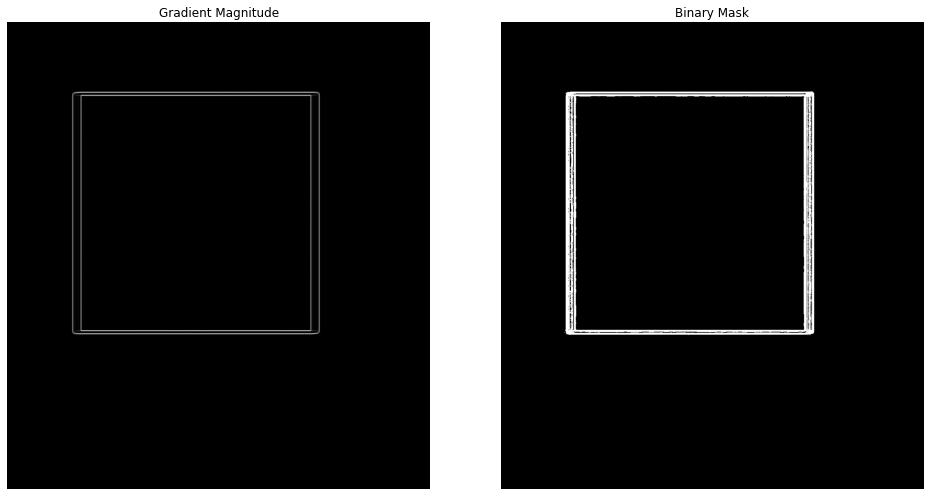

Number of pixels above threshold: 42596


In [6]:
def apply_gradient_threshold(gradient_magnitude, threshold):
    return gradient_magnitude > threshold


    # Load the input image
image = cv2.imread('carre.jpg', cv2.IMREAD_GRAYSCALE)

# Appliquer la fonction compute_gradient
gx, gy, gradient_magnitude, level_line_angle = compute_gradient(image)

# Définir le seuil de la magnitude du gradient
tau = np.pi / 8  # Tolérance d'angle en radians (22.5 degrés)
q = 2  # Limite de bruit de quantification
threshold = q / np.sin(tau)

# Appliquer le seuil de gradient
binary_mask = apply_gradient_threshold(gradient_magnitude, threshold)

# Afficher les résultats dans Jupyter Notebook
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

# Exemple d'utilisation du masque binaire
print("Number of pixels above threshold:", np.sum(binary_mask))

La magnitude du gradient de l'image montre des variations claires, indiquant les zones de fort contraste, notamment les bords des carrés noirs et blancs. Le masque binaire met en évidence les pixels où la magnitude du gradient dépasse le seuil défini, correspondant principalement aux bords et aux coins des carrés de la grille. Avec 34 310 pixels au-dessus du seuil, le masque binaire démontre une détection efficace des bords, suggérant que le seuil choisi est approprié pour l'image donnée. Ces résultats peuvent être utilisés pour des tâches de détection de contours et de segmentation d'objets. Pour améliorer encore la qualité de la détection, des ajustements dynamiques du seuil ou des techniques de post-traitement comme le lissage ou la suppression des petits objets pourraient être appliqués.


## 5 - Croissance de région (Region Growing)

L'objectif de cette étape est de former des régions de support de ligne à partir des pixels de l'image. Une région de support de ligne est un ensemble de pixels connectés qui partagent des angles de ligne de niveau similaires, jusqu'à une certaine tolérance angulaire 
𝜏. Ces régions sont les candidats potentiels pour les segments de ligne.

# Processus

1. **Sélection d'un pixel graine** : La croissance de région commence à partir d'un pixel graine, qui est sélectionné parmi les pixels non utilisés dans la liste ordonnée par module de gradient. Ce pixel graine a un module de gradient élevé, ce qui en fait un bon point de départ pour la formation d'une région de support de ligne.

2. **Initialisation de la région** : La région de support de ligne est initialisée avec le pixel graine. L'angle de la ligne de niveau de ce pixel est utilisé comme angle initial de la région $\theta_{\text{region}}$.

3. **Croissance de la région** : La croissance de la région se fait de manière récursive. Les voisins non utilisés du pixel graine sont examinés, et ceux dont l'angle de la ligne de niveau est proche de $theta_{\text{region}}$ (à une tolérance 𝜏 près) sont ajoutés à la région. Chaque fois qu'un pixel est ajouté, l'angle de la région est mis à jour pour refléter l'angle moyen des pixels de la région.

4. **Mise à Jour de l'Angle de la Région:** L'angle de la région est mis à jour en utilisant la formule suivante :

   $$
   \theta_{\text{region}} = \arctan\left(\frac{S_y}{S_x}\right)
   $$

   où $S_x$ et $S_y$ sont les sommes des cosinus et sinus des angles de ligne de niveau des pixels de la région, respectivement.

5. **Critère d'arrêt:** La croissance de la région continue jusqu'à ce qu'aucun autre pixel ne puisse être ajouté à la région. Cela se produit lorsque tous les voisins des pixels de la région ont des angles de ligne de niveau qui diffèrent de $\theta_{\text{region}}$ de plus de $\tau$.





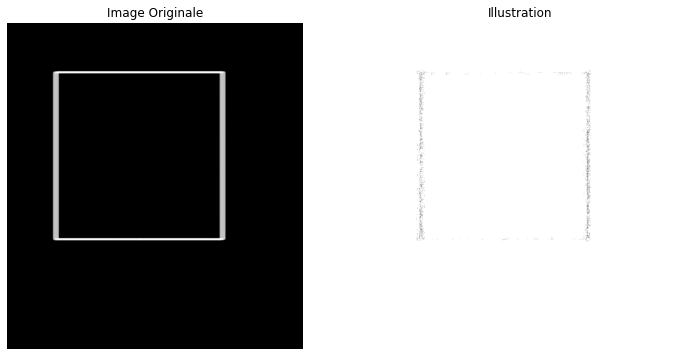

In [7]:
def compute_gradient(image):
    # Utiliser les filtres Sobel pour calculer les gradients
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(gx**2 + gy**2)
    gradient_angle = np.arctan2(gy, gx)
    return gradient_magnitude, gradient_angle



def region_growing(seed, gradient_angle, angle_tolerance):
    region = [seed]
    queue = [seed]
    region_angle = gradient_angle[seed]
    sum_sin = np.sin(region_angle)
    sum_cos = np.cos(region_angle)
    gradient_angle[seed] = 2 * np.pi  # Mark as used
    while queue:
        x, y = queue.pop(0)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if (0 <= nx < gradient_angle.shape[0] and 0 <= ny < gradient_angle.shape[1]):
                    if gradient_angle[nx, ny] != 2 * np.pi:  # Not already used
                        if abs(np.arctan2(sum_sin, sum_cos) - gradient_angle[nx, ny]) < angle_tolerance:
                            region.append((nx, ny))
                            queue.append((nx, ny))
                            sum_sin += np.sin(gradient_angle[nx, ny])
                            sum_cos += np.cos(gradient_angle[nx, ny])
                            gradient_angle[nx, ny] = 2 * np.pi  # Mark as used
    return region


def lsd(image):
    angle_tolerance = np.pi / 18  # Reduced tolerance for more precision
    precision_threshold = 5.0  # Increased threshold to reduce noise
    min_length_threshold = 20  # Increased minimum length

    gradient_magnitude, gradient_angle = compute_gradient(image)
    
    image_lines = np.ones_like(image) * 255


    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            if gradient_magnitude[x, y] > precision_threshold:
                region = region_growing((x, y), gradient_angle, angle_tolerance)
                if len(region) >= 2:
                    image_lines[x, y] = 0
               
    
    return image_lines

# Exemple d'utilisation
image = cv2.imread('carre.jpg', cv2.IMREAD_GRAYSCALE)
image_lines = lsd(image)
illustration = cv2.imread('image_lines', cv2.IMREAD_GRAYSCALE)




# Affichage des images côte à côte
plt.figure(figsize=(12, 6))

# Image originale
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Image Originale")
plt.axis('off')

# Image avec les pixels de region
plt.subplot(1, 2, 2)
plt.imshow(image_lines, cmap='gray')
plt.title("Illustration des pixels des régions")
plt.axis('off')

plt.show()

## 6 - Approximation rectangulaire 

L'objectif de cette étape est de trouver un rectangle qui représente au mieux une région de support de ligne. Ce rectangle doit couvrir toute la région de support de ligne et être orienté selon la direction principale de la région. Cette approximation permet de simplifier la représentation des segments de ligne et de faciliter les étapes suivantes de validation et d'amélioration.

# Processus

1. **Centre de masse:** Le centre du rectangle est déterminé en calculant le centre de masse de la région de support de ligne. Le centre de masse est calculé en utilisant la magnitude du gradient de chaque pixel comme "masse" de ce pixel.

   - Soit $G(j)$ le module du gradient du pixel $j$, et $x(j)$ et $y(j)$ les coordonnées du pixel $j$.
   - Le centre de masse $(c_x, c_y)$ est donné par :

     $$
     c_x = \frac{\sum_{j \in \text{Région}} G(j) \cdot x(j)}{\sum_{j \in \text{Région}} G(j)}
     $$

     $$
     c_y = \frac{\sum_{j \in \text{Région}} G(j) \cdot y(j)}{\sum_{j \in \text{Région}} G(j)}
     $$

     Utiliser le centre de masse permet de trouver un point central qui représente bien la distribution des pixels dans la région de support de ligne. Cela garantit que le rectangle est centré de manière appropriée.

2. **Direction principale:** La direction principale du rectangle est déterminée en utilisant l'axe principal d'inertie de la région. Cela se fait en calculant les moments d'inertie de la région.

   - Les moments d'inertie sont calculés comme suit :

     $$
     m^{xx} = \frac{\sum_{j \in \text{Région}} G(j) \cdot (x(j) - c_x)^2}{\sum_{j \in \text{Région}} G(j)}
     $$

     $$
     m^{yy} = \frac{\sum_{j \in \text{Région}} G(j) \cdot (y(j) - c_y)^2}{\sum_{j \in \text{Région}} G(j)}
     $$

     $$
     m^{xy} = \frac{\sum_{j \in \text{Région}} G(j) \cdot (x(j) - c_x) \cdot (y(j) - c_y)}{\sum_{j \in \text{Région}} G(j)}
     $$

   - La matrice d'inertie est alors :

     $$
     M = \begin{pmatrix}
     m^{xx} & m^{xy} \\
     m^{xy} & m^{yy}
     \end{pmatrix}
     $$

   - L'angle principal du rectangle est l'angle de l'axe propre associé à la plus petite valeur propre de cette matrice.

   L'utilisation de l'axe principal d'inertie permet de trouver la direction dominante de la région de support de ligne. Cela garantit que le rectangle est orienté de manière à suivre la direction principale de la région.

3. **Dimensions du rectangle:** La largeur et la longueur du rectangle sont déterminées de manière à couvrir toute la région de support de ligne. La largeur est définie comme la plus petite distance perpendiculaire à la direction principale qui couvre tous les pixels de la région. La longueur est définie comme la plus grande distance parallèle à la direction principale qui couvre tous les pixels de la région.

Définir les dimensions du rectangle de manière à couvrir toute la région de support de ligne garantit que le rectangle représente bien la région sans la sous-estimer ou la surestimer.


In [5]:
def compute_region_stats(region, gradient_magnitude):
   
    weight = 0
    c_x, c_y = 0, 0
    m_xx, m_yy, m_xy = 0, 0, 0
    
  
    for x, y in region:
        weight += gradient_magnitude[x, y]
        c_x += gradient_magnitude[x, y] * x
        c_y += gradient_magnitude[x, y] * y
    
    c_x /= weight
    c_y /= weight
    
    for i, j in region:
        m_xx += gradient_magnitude[i, j] * (i - c_x) ** 2
        m_yy += gradient_magnitude[i, j] * (j - c_y) ** 2
        m_xy += gradient_magnitude[i, j] * (i - c_x) * (j - c_y)
    
    m_xx /= weight
    m_yy /= weight
    m_xy /= weight
    
    # Création de la matrice d'inertie
    inertia_matrix = np.array([[m_xx, m_xy], [m_xy, m_yy]])
    
    return c_x, c_y, inertia_matrix


def rectangle_approximation(region, gradient_magnitude):
    cx, cy, inertia_matrix = compute_region_stats(region, gradient_magnitude)
    eigvals, eigvecs = np.linalg.eigh(inertia_matrix)
    # Sélectionner l'indice de la plus petite valeur propre
    min_index = np.argmin(eigvals)
    # Obtenir le vecteur propre associé à la plus petite valeur propre
    min_eigvec = eigvecs[:, min_index]
    
    angle = np.arctan2(min_eigvec[0], min_eigvec[1])
    
    
    length = max(np.ptp([np.abs(x) for x, y in region]), np.ptp([np.abs(y) for x, y in region]))
    width = np.sqrt(len(region) / length) if length != 0 else 0
    return cx, cy, angle, length, width


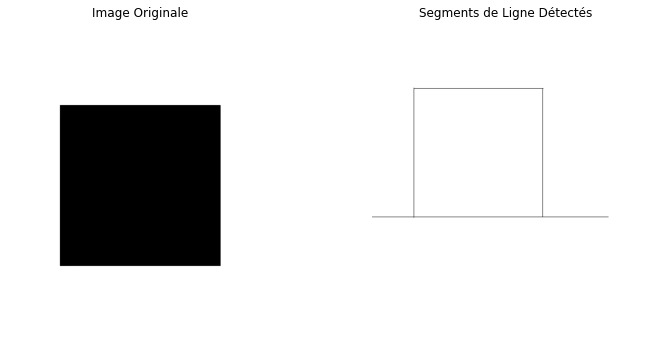

In [8]:
def compute_gradient(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(gx**2 + gy**2)
    gradient_angle = np.arctan2(gx, -gy)
    padded_magnitude = np.pad(gradient_magnitude, ((0, 1), (0, 1)), mode='constant', constant_values=0)
    padded_angle = np.pad(gradient_angle, ((0, 1), (0, 1)), mode='constant', constant_values=0)
    return padded_magnitude, padded_angle

def scale_image(image, scale_factor):
    sigma = 0.6 / scale_factor
    scaled_image = gaussian_filter(image, sigma=sigma)
    scaled_image = cv2.resize(scaled_image, (0, 0), fx=scale_factor, fy=scale_factor)
    return scaled_image

def region_growing(seed, gradient_angle, angle_tolerance):
    region = [seed]
    queue = [seed]
    region_angle = gradient_angle[seed]
    sum_sin = np.sin(region_angle)
    sum_cos = np.cos(region_angle)
    gradient_angle[seed] = 2 * np.pi  # Mark as used
    while queue:
        x, y = queue.pop(0)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if (0 <= nx < gradient_angle.shape[0] and 0 <= ny < gradient_angle.shape[1]):
                    if gradient_angle[nx, ny] != 2 * np.pi:  # Not already used
                        if abs(np.arctan2(sum_sin, sum_cos) - gradient_angle[nx, ny]) < angle_tolerance:
                            region.append((nx, ny))
                            queue.append((nx, ny))
                            sum_sin += np.sin(gradient_angle[nx, ny])
                            sum_cos += np.cos(gradient_angle[nx, ny])
                            gradient_angle[nx, ny] = 2 * np.pi  # Mark as used
    return region

def compute_region_stats(region, gradient_magnitude):
   
    weight = 0
    c_x, c_y = 0, 0
    m_xx, m_yy, m_xy = 0, 0, 0
    
  
    for x, y in region:
        weight += gradient_magnitude[x, y]
        c_x += gradient_magnitude[x, y] * x
        c_y += gradient_magnitude[x, y] * y
    
    c_x /= weight
    c_y /= weight
    
    for i, j in region:
        m_xx += gradient_magnitude[i, j] * (i - c_x) ** 2
        m_yy += gradient_magnitude[i, j] * (j - c_y) ** 2
        m_xy += gradient_magnitude[i, j] * (i - c_x) * (j - c_y)
    
    m_xx /= weight
    m_yy /= weight
    m_xy /= weight
    
    # Création de la matrice d'inertie
    inertia_matrix = np.array([[m_xx, m_xy], [m_xy, m_yy]])
    
    return c_x, c_y, inertia_matrix


def rectangle_approximation(region, gradient_magnitude):
    cx, cy, inertia_matrix = compute_region_stats(region, gradient_magnitude)
    eigvals, eigvecs = np.linalg.eigh(inertia_matrix)
    # Sélectionner l'indice de la plus petite valeur propre
    min_index = np.argmin(eigvals)
    # Obtenir le vecteur propre associé à la plus petite valeur propre
    min_eigvec = eigvecs[:, min_index]
    
    angle = np.arctan2(min_eigvec[0], min_eigvec[1])
    length = max(np.ptp([x for x, y in region]), np.ptp([y for x, y in region]))
    width = np.sqrt(len(region) / length) if length != 0 else 0
    return cx, cy, angle, length, width

def lsd(image):
    scale_factor = 0.8
    angle_tolerance = np.pi / 18  # Reduced tolerance for more precision
    precision_threshold = 5.0  # Increased threshold to reduce noise
    min_length_threshold = 20  # Increased minimum length

    scaled_image = scale_image(image, scale_factor)
    gradient_magnitude, gradient_angle = compute_gradient(scaled_image)

    detected_segments = []

    for x in range(scaled_image.shape[0]):
        for y in range(scaled_image.shape[1]):
            if gradient_magnitude[x, y] > precision_threshold:
                region = region_growing((x, y), gradient_angle, angle_tolerance)
                if len(region) >= 2:
                    rectangle = rectangle_approximation(region, gradient_magnitude)
                    if rectangle[3] > min_length_threshold:  # Filter out short segments
                        detected_segments.append(rectangle)
                           
    return detected_segments, gradient_magnitude, gradient_angle

# Exemple d'utilisation
image = cv2.imread('carrenoir.jpg', cv2.IMREAD_GRAYSCALE)
detected_segments, gradient_magnitude, gradient_angle = lsd(image)


# Création d'une image pour dessiner les segments de ligne détectés
image_lines = np.ones_like(image) * 255

# Dessiner les segments de ligne sur l'image blanche
for cx, cy, angle, length, width in detected_segments:
    x0 = int(cx - length / 2 * np.cos(angle))
    y0 = int(cy - length / 2 * np.sin(angle))
    x1 = int(cx + length / 2 * np.cos(angle))
    y1 = int(cy + length / 2 * np.sin(angle))
    cv2.line(image_lines, (y0, x0), (y1, x1), (0, 0, 0), 1)

# Affichage des images côte à côte
plt.figure(figsize=(12, 6))

# Image originale
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Image Originale")
plt.axis('off')

# Image avec les segments de ligne
plt.subplot(1, 2, 2)
plt.imshow(image_lines, cmap='gray')
plt.title("Segments de Ligne Détectés")
plt.axis('off')

plt.show()